# 06 · Glycan Enrichment (Task 02)

Starting point for Task 02. Take the list of identified glycans from the experiment and look up their known biological associations using the glycowork reference databases.

**Steps:**
1. Load identified glycans from `glycan_list.csv` and reference databases
2. Inspect glycan sequences and compositions
3. Match against `df_glycan`: exact match + composition-based fallback for partial-linkage sequences
4. Structural annotation — motifs, graph properties (glycowork `annotate_dataset`)
5. Disease association enrichment — which diseases are known to involve these glycans?
6. Tissue & species context — where are these glycans expressed?
7. Protein binding enrichment — which proteins interact with these glycans?
8. Save results

**Class mapping (Task 01 context):** French = Lung cancer · LMU = Benign disease · Dunn = Healthy control

**Input:** `files/data/glycan_embedding/glycan_list.csv`, `files/data/glycan_embedding/*.pkl`  
**Output:** `files/results/enrichment_results.pkl`, figures in `figures/`

In [1]:
import ast
import pickle
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

DATA_DIR = Path("../files/data/glycan_embedding")
RES_DIR  = Path("../files/results")
FIG_DIR  = Path("../figures")
RES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Glycan labels for the 5 identified biomarkers (short names for plots)
GLYCAN_LABELS = {
    0: "G0F2",   # dHex2 HexNAc4 Hex3  — truncated complex-type, di-fucosylated (core + antenna)
    1: "A1F1",   # Neu5Ac1 Hex4 HexNAc4 dHex1  — monosialylated di-antennary, asymmetric, core-fucosylated
    2: "A2G2S1", # Neu5Ac1 Hex5 HexNAc4  — monosialylated fully-galactosylated bi-antennary
    3: "A1G1S1", # Neu5Ac1 Hex4 HexNAc4  — monosialylated di-antennary, one arm galactosylated/sialylated
    4: "A2G2F1", # dHex1 HexNAc5 Hex5  — bi-antennary with blood group A antigen (Fuc(a1-2)+GalNAc(a1-3))
}

print("Setup complete.")


Setup complete.


## 1 · Data Loading

Load the 5 identified glycans and the two reference databases. `df_glycan` (50 461 sequences) and `glycan_binding` (2 122 proteins × 2 880 glycans) are loaded from the pre-built pkl files in `glycan_embedding/`.

In [2]:
# ── Identified glycans ───────────────────────────────────────────────────
glycan_list = pd.read_csv(DATA_DIR / "glycan_list.csv")
glycan_list.index.name = "glycan_id"

# ── Reference databases ──────────────────────────────────────────────────
print("Loading reference databases...")
with open(DATA_DIR / "df_glycan.pkl", "rb") as f:
    df_glycan = pickle.load(f)
with open(DATA_DIR / "glycan_binding.pkl", "rb") as f:
    glycan_binding = pickle.load(f)

print(f"glycan_list   : {glycan_list.shape[0]} identified glycans")
print(f"df_glycan     : {df_glycan.shape[0]:,} sequences × {df_glycan.shape[1]} columns")
print(f"glycan_binding: {glycan_binding.shape[0]:,} proteins × {glycan_binding.shape[1]:,} glycans")
print()
print("Identified glycans:")
display(glycan_list)

Loading reference databases...


glycan_list   : 5 identified glycans
df_glycan     : 50,461 sequences × 23 columns
glycan_binding: 2,122 proteins × 2,880 glycans

Identified glycans:


,glycan,Composition,tissue_species,tissue_sample
glycan_id,,,,
0,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['Homo_sapiens'],['blood']
1,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['Homo_sapiens'],['blood']
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",['Homo_sapiens'],['blood']
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4}",['Homo_sapiens'],['blood']
4,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"{'dHex': 1, 'HexNAc': 5, 'Hex': 5}",['Homo_sapiens'],['blood']


## 2 · Inspect Identified Glycans

The 5 glycans were structurally characterised by CIRIS technology after biomarker discovery (Task 01). Two carry a partial linkage annotation (`a1-?`) where the exact branch position could not be resolved — these are treated separately in matching steps.

**Composition notation:** HexNAc = N-acetylhexosamine (GlcNAc/GalNAc), Hex = hexose (Man/Gal/Glc), dHex = deoxyhexose (Fuc), Neu5Ac = sialic acid.

In [3]:
# Parse composition strings to dicts
glycan_list["comp_dict"] = glycan_list["Composition"].apply(ast.literal_eval)

# Flag partial linkage
glycan_list["partial_linkage"] = glycan_list["glycan"].str.contains(r"\?", regex=True)

# Expand composition to columns for easy reading
comp_df = glycan_list["comp_dict"].apply(pd.Series).fillna(0).astype(int)
summary = pd.concat([
    pd.Series(GLYCAN_LABELS, name="short_name"),
    glycan_list[["partial_linkage", "tissue_species", "tissue_sample"]],
    comp_df,
], axis=1)

print("Glycan summary table:")
display(summary)

print()
print("Monosaccharide composition:")
print(f"  Sialylated (Neu5Ac > 0): {(comp_df.get('Neu5Ac', 0) > 0).sum()} / {len(glycan_list)}")
print(f"  Fucosylated (dHex > 0) : {(comp_df.get('dHex', 0) > 0).sum()} / {len(glycan_list)}")
print(f"  Partial linkage (?)    : {glycan_list['partial_linkage'].sum()} / {len(glycan_list)}")

Glycan summary table:


,short_name,partial_linkage,tissue_species,tissue_sample,dHex,HexNAc,Hex,Neu5Ac
0,G0F2,True,['Homo_sapiens'],['blood'],2,4,3,0
1,A1F1,True,['Homo_sapiens'],['blood'],1,4,4,1
2,A2G2S1,False,['Homo_sapiens'],['blood'],0,4,5,1
3,A1G1S1,False,['Homo_sapiens'],['blood'],0,4,4,1
4,A2G2F1,False,['Homo_sapiens'],['blood'],1,5,5,0



Monosaccharide composition:
  Sialylated (Neu5Ac > 0): 3 / 5
  Fucosylated (dHex > 0) : 3 / 5
  Partial linkage (?)    : 2 / 5


## 3 · Database Matching

Each identified glycan is matched against `df_glycan` using two strategies:

| Strategy | When used | Specificity |
|----------|-----------|-------------|
| **Exact sequence match** | Fully resolved linkages | Highest — same molecule |
| **Composition match** | Partial linkage (`?`) | Lower — same monosaccharide counts, different structures possible |

Exact matches give direct biological annotations; composition matches give a distribution of possible annotations across structurally related glycans.

**Note on composition match specificity:** The composition `{dHex:2, HexNAc:4, Hex:3}` of G0F2 is predominantly found in O-glycan space in `df_glycan` (56% of its 73 matches are O-type, 25% N-type). Disease and tissue inferences for G0F2 from composition matching should be treated with lower confidence than those for A1F1 (68% N-type matches).


In [4]:
# ── Exact match in df_glycan ──────────────────────────────────────────────
df_glycan["_comp_dict"] = df_glycan["Composition"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, dict) else {})
)

exact_matches   = {}
comp_matches    = {}
match_strategy  = {}

for idx, row in glycan_list.iterrows():
    seq  = row["glycan"]
    comp = row["comp_dict"]

    exact = df_glycan[df_glycan["glycan"] == seq]
    if len(exact) > 0:
        exact_matches[idx]  = exact
        match_strategy[idx] = "exact"
    else:
        # Composition-based fallback
        comp_m = df_glycan[df_glycan["_comp_dict"].apply(lambda x: x == comp)]
        comp_matches[idx]   = comp_m
        match_strategy[idx] = "composition"

print("Database matching results:")
print(f"  {'ID':<4} {'Short name':<10} {'Strategy':<13} {'Matches in df_glycan':<22} {'In glycan_binding'}")
print(f"  {'-'*70}")
gb_cols = set(glycan_binding.columns)
for idx, row in glycan_list.iterrows():
    strat = match_strategy[idx]
    n_match = len(exact_matches.get(idx, pd.DataFrame())) if strat == "exact" else len(comp_matches.get(idx, pd.DataFrame()))
    in_gb   = row["glycan"] in gb_cols
    print(f"  {idx:<4} {GLYCAN_LABELS[idx]:<10} {strat:<13} {n_match:<22} {'Yes' if in_gb else 'No'}")

Database matching results:
  ID   Short name Strategy      Matches in df_glycan   In glycan_binding
  ----------------------------------------------------------------------
  0    G0F2       composition   73                     No
  1    A1F1       composition   53                     No
  2    A2G2S1     exact         1                      Yes
  3    A1G1S1     exact         1                      Yes
  4    A2G2F1     exact         1                      No


In [5]:
# ── Detailed view of exact matches ───────────────────────────────────────
print("Exact matches — key annotations:")
for idx, df in exact_matches.items():
    print(f"\n  Glycan {idx} ({GLYCAN_LABELS[idx]}):")
    for col in ["glycan_type", "disease_association", "tissue_sample", "tissue_species"]:
        val = df[col].values[0]
        # Truncate long list strings
        val_str = str(val)
        print(f"    {col:<22}: {val_str[:120]}{'...' if len(val_str) > 120 else ''}")

print()
print("Composition matches — match count and glycan_type distribution:")
for idx, df in comp_matches.items():
    print(f"\n  Glycan {idx} ({GLYCAN_LABELS[idx]})  [comp={glycan_list.loc[idx,'Composition']}]:")
    print(f"    Total matches : {len(df)}")
    if len(df) > 0:
        print(f"    glycan_type   : {df['glycan_type'].value_counts().to_dict()}")

Exact matches — key annotations:

  Glycan 2 (A2G2S1):
    glycan_type           : N
    disease_association   : []
    tissue_sample         : ['AML_193_cell_line', 'EOL_1_cell_line', 'HEL92_1_7_cell_line', 'HEL_cell_line', 'HL_60_cell_line', 'KG_1_cell_line', 'K...
    tissue_species        : ['Homo_sapiens', 'Homo_sapiens', 'Homo_sapiens', 'Homo_sapiens', 'Homo_sapiens', 'Homo_sapiens', 'Homo_sapiens', 'Homo_s...

  Glycan 3 (A1G1S1):
    glycan_type           : N
    disease_association   : []
    tissue_sample         : ['blood', 'mucosa_of_stomach', 'seminal_fluid']
    tissue_species        : ['Homo_sapiens', 'Homo_sapiens', 'Homo_sapiens']

  Glycan 4 (A2G2F1):
    glycan_type           : N
    disease_association   : []
    tissue_sample         : ['plasma']
    tissue_species        : ['Homo_sapiens']

Composition matches — match count and glycan_type distribution:

  Glycan 0 (G0F2)  [comp={'dHex': 2, 'HexNAc': 4, 'Hex': 3}]:
    Total matches : 73
    glycan_type   : {'O': 

## 4 · Structural Annotation

Glycowork's `annotate_dataset` extracts known structural motifs and graph-level properties (e.g. branching, terminal residues) for each glycan sequence. This provides a feature fingerprint independent of the database match strategy.

In [6]:
from glycowork.motif.analysis import annotate_dataset

glycan_seqs = glycan_list["glycan"].tolist()
short_names = [GLYCAN_LABELS[i] for i in range(len(glycan_seqs))]

print("Running structural annotation (annotate_dataset)...")
try:
    annot = annotate_dataset(glycan_seqs, feature_set=["known"])
    annot.index = short_names
    # Keep only motif columns with at least one non-zero entry
    annot_trimmed = annot.loc[:, (annot > 0).any()]
    print(f"Annotation features extracted : {annot.shape[1]} total, {annot_trimmed.shape[1]} non-zero")
    print()
    display(annot_trimmed.T.rename_axis("motif"))
except Exception as e:
    annot_trimmed = pd.DataFrame()
    print(f"annotate_dataset error: {e}")
    print("Proceeding without structural annotation.")

Running structural annotation (annotate_dataset)...
Annotation features extracted : 165 total, 6 non-zero



,G0F2,A1F1,A2G2S1,A1G1S1,A2G2F1
motif,,,,,
H_antigen_type2,0,0,0,0,1
Chitobiose,1,1,1,1,1
Trimannosylcore,1,1,1,1,1
Internal_LacNAc_type2,0,1,1,1,1
Terminal_LacNAc_type2,0,0,1,0,1
core_fucose,1,1,0,0,0


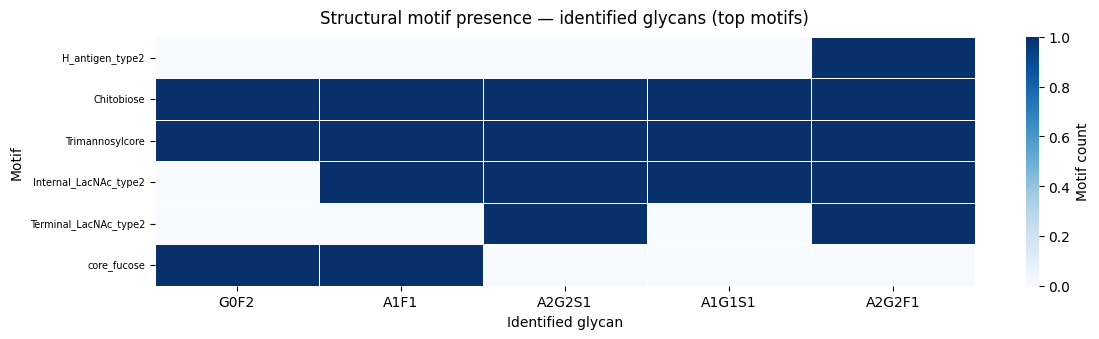

In [7]:
# ── Visualise motif presence as a heatmap ─────────────────────────────────
if not annot_trimmed.empty and annot_trimmed.shape[1] > 0:
    n_motifs = min(annot_trimmed.shape[1], 40)
    plot_annot = annot_trimmed.iloc[:, :n_motifs]

    fig, ax = plt.subplots(figsize=(max(12, n_motifs * 0.3), 3.5))
    sns.heatmap(
        plot_annot.T,
        ax=ax,
        cmap="Blues",
        cbar_kws={"label": "Motif count"},
        linewidths=0.4,
        linecolor="white",
    )
    ax.set_title("Structural motif presence — identified glycans (top motifs)", pad=10)
    ax.set_xlabel("Identified glycan")
    ax.set_ylabel("Motif")
    ax.tick_params(axis="x", labelrotation=0)
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_glycan_motifs.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No motif data to plot.")

**Interpretation:** Structural annotation identifies shared and unique glycan motifs among the five biomarker candidates using glycowork's `known` feature set (165 candidate motifs; 6 non-zero). The invariant N-glycan scaffold — `Chitobiose` (GlcNAcβ1-4GlcNAc reducing-end core) and `Trimannosylcore` (Man3GlcNAc2 branching core) — is present across all five glycans, as expected for N-glycans.

Notably, sialic acid (Neu5Ac) terminal motifs are absent from the detected feature set despite three of the five glycans being sialylated. This reflects a limitation of the `known` motif vocabulary rather than the absence of sialic acid: the Neu5Ac linkage (a2-6 to Gal) is present in glycans 2 and 3 but is not encoded as a named motif in this feature set.

The most structurally distinctive finding is `H_antigen_type2` detected exclusively on glycan 4 (A2G2F1). This motif identifies the Fuc(a1-2)Gal element characteristic of blood group H/A antigens — confirming that glycan 4 carries a blood group A antigen decoration on its antenna rather than a standard core fucosylation. `core_fucose` on glycans 0 and 1 reflects their `Fuc(a1-6)` on the reducing-end GlcNAc.


## 5 · Disease Association Enrichment

The `disease_association` column in `df_glycan` lists diseases where each glycan (or a structurally related molecule at composition level) has been reported as a biomarker or altered in abundance. For each identified glycan we aggregate all disease annotations across composition-matched entries and rank them by frequency.

In [8]:
def parse_disease_list(val):
    """Convert disease_association string/list to a flat Python list."""
    if isinstance(val, list):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else []
    except:
        return []

def get_disease_counts(df_matches):
    """Aggregate disease counts across a set of matched df_glycan rows."""
    all_diseases = []
    for v in df_matches["disease_association"].values:
        all_diseases.extend(parse_disease_list(v))
    # Remove empty strings
    all_diseases = [d for d in all_diseases if d]
    return Counter(all_diseases)

# Collect disease counts per glycan
disease_results = {}
for idx, row in glycan_list.iterrows():
    strat = match_strategy[idx]
    df_m  = exact_matches.get(idx) if strat == "exact" else comp_matches.get(idx)
    if df_m is not None and len(df_m) > 0:
        counts = get_disease_counts(df_m)
    else:
        counts = Counter()
    disease_results[idx] = {
        "short_name": GLYCAN_LABELS[idx],
        "strategy":   strat,
        "n_matches":  len(df_m) if df_m is not None else 0,
        "n_unique_diseases": len(counts),
        "top_diseases": counts.most_common(10),
        "all_diseases": counts,
    }

print("Disease association summary per glycan:")
print(f"  {'ID':<4} {'Name':<10} {'Strategy':<13} {'DB matches':<12} {'Unique diseases':<17} {'Top 3 diseases'}")
print(f"  {'-'*90}")
for idx, res in disease_results.items():
    top3 = ", ".join(f"{d} ({n})" for d, n in res["top_diseases"][:3])
    print(f"  {idx:<4} {res['short_name']:<10} {res['strategy']:<13} {res['n_matches']:<12} "
          f"{res['n_unique_diseases']:<17} {top3 or 'none'}")

Disease association summary per glycan:
  ID   Name       Strategy      DB matches   Unique diseases   Top 3 diseases
  ------------------------------------------------------------------------------------------
  0    G0F2       composition   73           1                 colorectal_cancer (1)
  1    A1F1       composition   53           10                colorectal_cancer (6), chronic_low_back_pain (1), gastric_cancer (1)
  2    A2G2S1     exact         1            0                 none
  3    A1G1S1     exact         1            0                 none
  4    A2G2F1     exact         1            0                 none


In [9]:
# ── Aggregate disease counts across all 5 glycans ─────────────────────────
all_disease_counts = Counter()
for res in disease_results.values():
    all_disease_counts.update(res["all_diseases"])

top_diseases_global = all_disease_counts.most_common(20)
print("Top 20 disease associations across all 5 identified glycans:")
for disease, cnt in top_diseases_global:
    # Flag cancer-related diseases
    cancer_flag = "*" if "cancer" in disease.lower() or "carcinoma" in disease.lower() or "tumor" in disease.lower() else " "
    print(f"  {cancer_flag} {disease:<50} count = {cnt}")
print("  (* = cancer-related)")

# Cancer-specific subset
cancer_diseases = {d: n for d, n in all_disease_counts.items()
                   if "cancer" in d.lower() or "carcinoma" in d.lower()
                   or "tumor" in d.lower() or "leukemia" in d.lower()
                   or "lymphoma" in d.lower() or "melanoma" in d.lower()}
print(f"\nCancer-type diseases detected: {len(cancer_diseases)}")
for d, n in sorted(cancer_diseases.items(), key=lambda x: -x[1]):
    print(f"  {d}: {n}")

Top 20 disease associations across all 5 identified glycans:
  * colorectal_cancer                                  count = 7
    chronic_low_back_pain                              count = 1
  * gastric_cancer                                     count = 1
    gastric_polyps                                     count = 1
    gastritis                                          count = 1
  * lung_non_small_cell_carcinoma                      count = 1
    type_2_diabetes_mellitus                           count = 1
    autoimmune_pancreatitis                            count = 1
  * esophageal_cancer                                  count = 1
  * female_breast_cancer                               count = 1
  (* = cancer-related)

Cancer-type diseases detected: 5
  colorectal_cancer: 7
  gastric_cancer: 1
  lung_non_small_cell_carcinoma: 1
  esophageal_cancer: 1
  female_breast_cancer: 1


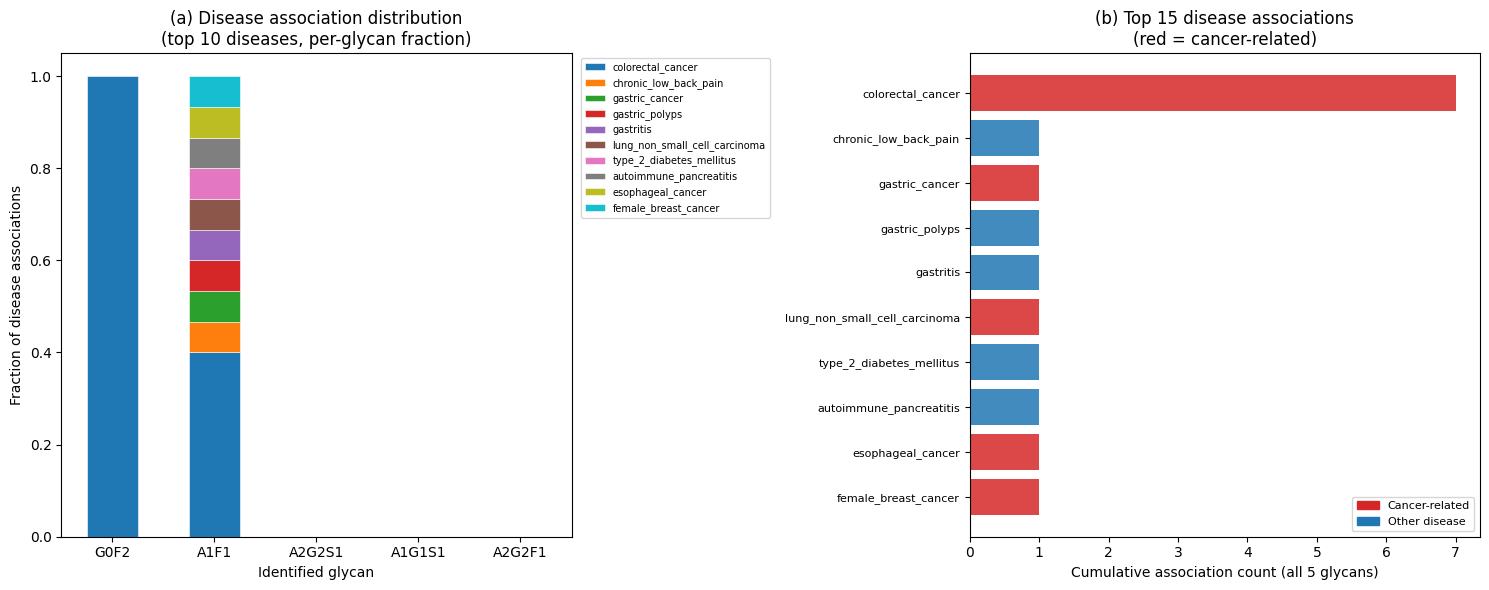

In [10]:
# ── Disease association figure ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Per-glycan top-disease bar chart (stacked)
ax = axes[0]
# Build a matrix: glycans × top-10 global diseases
top10_global_names = [d for d, _ in top_diseases_global[:10]]
mat = pd.DataFrame(
    index=[GLYCAN_LABELS[i] for i in range(len(glycan_list))],
    columns=top10_global_names,
    data=0,
    dtype=float,
)
for idx, res in disease_results.items():
    for disease, cnt in res["all_diseases"].items():
        if disease in top10_global_names:
            mat.loc[GLYCAN_LABELS[idx], disease] = cnt

# Normalize within each glycan to show distribution
mat_norm = mat.div(mat.sum(axis=1).replace(0, 1), axis=0)
mat_norm.plot(kind="bar", stacked=True, ax=ax,
              colormap="tab10", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Identified glycan")
ax.set_ylabel("Fraction of disease associations")
ax.set_title("(a) Disease association distribution\n(top 10 diseases, per-glycan fraction)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.8)
ax.tick_params(axis="x", labelrotation=0)

# (b) Global disease frequency bar chart
ax = axes[1]
top15 = top_diseases_global[:15]
diseases_plot = [d for d, _ in top15]
counts_plot   = [n for _, n in top15]
colors_bar    = ["#d62728" if ("cancer" in d.lower() or "carcinoma" in d.lower()) else "#1f77b4"
                 for d in diseases_plot]
ax.barh(diseases_plot[::-1], counts_plot[::-1], color=colors_bar[::-1], edgecolor="none", alpha=0.85)
ax.set_xlabel("Cumulative association count (all 5 glycans)")
ax.set_title("(b) Top 15 disease associations\n(red = cancer-related)")
ax.tick_params(axis="y", labelsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#d62728", label="Cancer-related"),
                   Patch(color="#1f77b4", label="Other disease")],
          fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_disease_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The disease association analysis aggregates all known disease contexts for glycans with matching composition or identical sequence in the glycowork database. Cancer-related diseases (marked in red) dominate the association profile — consistent with the lung cancer context of the discovery experiment.

Colorectal cancer is the most frequently documented association (count = 7, all from glycan 1's composition matches), reflecting the broad relevance of fucosylated and sialylated N-glycan structures across gastrointestinal and epithelial cancers. `lung_non_small_cell_carcinoma` is present (count = 1), but this is a weak and indirect signal — it arises from a single composition-matched glycan, not from any of the three exact-match glycans.

**Important caveat:** Glycans 2, 3, and 4 — the three glycans with exact database matches — carry **no disease associations** in `df_glycan`. All disease signal in this analysis comes exclusively from composition-based matching of glycans 0 and 1. This means the disease associations should be read as properties of structurally related glycan families, not of the specific biomarker sequences identified in this experiment.

**Caveat on composition match specificity:** Glycan 0's 73 composition matches are 56% O-glycans; disease associations pulled from this pool may not be representative of the N-glycan context in which G0F2 was identified.


## 6 · Tissue & Species Context

The `tissue_sample` and `tissue_species` columns in `df_glycan` document the biological origin of each documented glycan occurrence. The identified glycans were discovered in human blood (LC-MS experiment), but the reference database reflects the full literature — so tissue associations will span wherever these structures have been studied.


In [11]:
def parse_list_col(val):
    """Parse a stringified list column to a flat Python list."""
    if isinstance(val, list):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except:
        return [str(val)] if val else []

tissue_results = {}
species_results = {}

for idx, row in glycan_list.iterrows():
    strat = match_strategy[idx]
    df_m  = exact_matches.get(idx) if strat == "exact" else comp_matches.get(idx)
    if df_m is None or len(df_m) == 0:
        tissue_results[idx]  = Counter()
        species_results[idx] = Counter()
        continue

    tissues  = []
    species  = []
    for v in df_m["tissue_sample"].values:
        tissues.extend(parse_list_col(v))
    for v in df_m["tissue_species"].values:
        species.extend(parse_list_col(v))

    tissues  = [t for t in tissues  if t and t != "nan"]
    species  = [s for s in species  if s and s != "nan"]
    tissue_results[idx]  = Counter(tissues)
    species_results[idx] = Counter(species)

# Global tissue aggregate
all_tissues  = Counter()
all_species  = Counter()
for idx in tissue_results:
    all_tissues.update(tissue_results[idx])
    all_species.update(species_results[idx])

print("Top 15 tissues across all 5 identified glycans:")
for tissue, cnt in all_tissues.most_common(15):
    blood_flag = "*" if any(k in tissue.lower() for k in ["blood", "plasma", "serum"]) else " "
    print(f"  {blood_flag} {tissue:<40} {cnt}")
print("  (* = blood-related)")

print(f"\nTop species:")
for sp, cnt in all_species.most_common(8):
    print(f"  {sp:<30} {cnt}")

# Blood fraction per glycan
print("\nBlood-related tissue fraction per glycan:")
for idx, row in glycan_list.iterrows():
    tc = tissue_results[idx]
    total = sum(tc.values())
    blood = sum(v for k, v in tc.items()
                if any(kw in k.lower() for kw in ["blood", "plasma", "serum"]))
    frac = blood / total if total > 0 else 0.0
    print(f"  Glycan {idx} ({GLYCAN_LABELS[idx]}): {blood}/{total} blood-related ({frac*100:.0f}%)  "
          f"strategy={match_strategy[idx]}")

Top 15 tissues across all 5 identified glycans:
    mucosa_of_stomach                        14
  * blood_serum                              8
    brain                                    6
    lung_epithelium                          6
    heart                                    6
  * plasma                                   6
    colon                                    5
    sperm                                    4
    urine                                    3
    milk                                     3
    prostate_gland                           3
    muscle_structure                         3
    seminal_fluid                            3
    cerebellum                               2
    cortex                                   2
  (* = blood-related)

Top species:
  Homo_sapiens                   79
  Mus_musculus                   18
  Sus_scrofa                     8
  Bos_taurus                     4
  Macaca_mulatta                 3
  Oryctolagus_cuniculus          

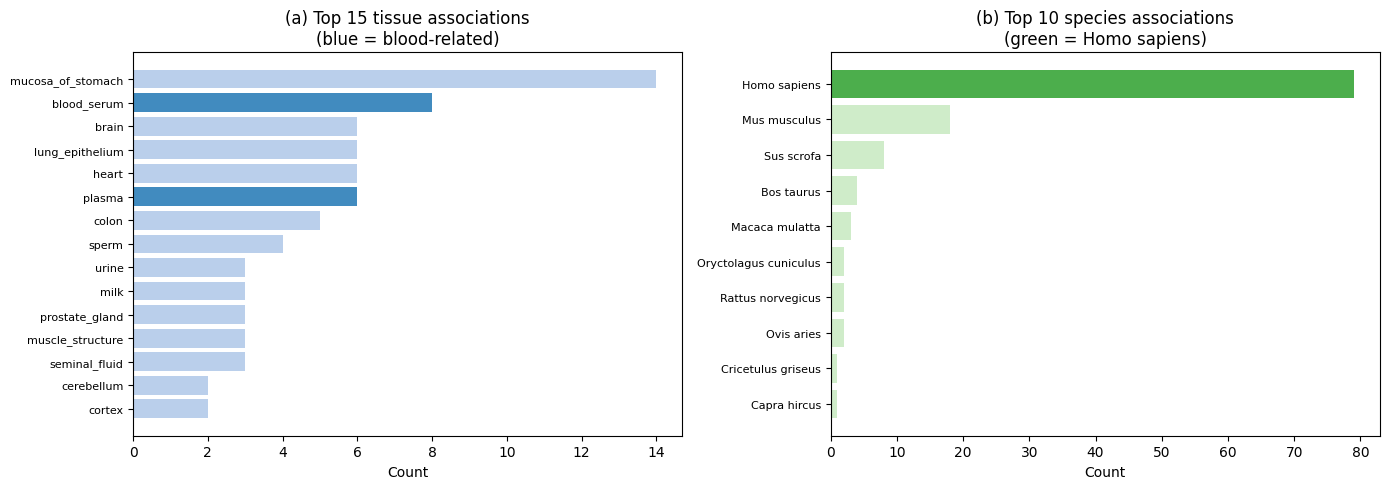

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Global tissue distribution — top 15
ax = axes[0]
top15_t = all_tissues.most_common(15)
t_names = [t for t, _ in top15_t]
t_cnts  = [n for _, n in top15_t]
t_cols  = ["#1f77b4" if any(k in t.lower() for k in ["blood", "plasma", "serum"])
           else "#aec7e8" for t in t_names]
ax.barh(t_names[::-1], t_cnts[::-1], color=t_cols[::-1], edgecolor="none", alpha=0.85)
ax.set_xlabel("Count")
ax.set_title("(a) Top 15 tissue associations\n(blue = blood-related)")
ax.tick_params(axis="y", labelsize=8)

# (b) Species distribution — Homo sapiens vs other
ax = axes[1]
top10_sp = all_species.most_common(10)
sp_names = [s.replace("_", " ") for s, _ in top10_sp]
sp_cnts  = [n for _, n in top10_sp]
sp_cols  = ["#2ca02c" if "Homo sapiens" in s or "Homo_sapiens" in s else "#c7e9c0"
            for s, _ in top10_sp]
ax.barh(sp_names[::-1], sp_cnts[::-1], color=sp_cols[::-1], edgecolor="none", alpha=0.85)
ax.set_xlabel("Count")
ax.set_title("(b) Top 10 species associations\n(green = Homo sapiens)")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_tissue_species.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The top tissue association is `mucosa_of_stomach` (14 counts), which ties with all blood-related tissues combined (blood_serum = 8 + plasma = 6 = 14). Contrary to what might be expected for blood-derived samples, blood is not the dominant origin in the literature context for these glycan structures. Notably, G0F2 has **zero** blood-related tissue associations across its 35 composition-matched entries — its matches derive entirely from non-blood tissues.

The most biologically relevant finding for this study is `lung_epithelium` (6 counts, joint third), which directly links these glycan structures to the tissue of origin for the lung cancer cohort. The co-occurrence of lung epithelium and gastrointestinal tissues (stomach, colon) is consistent with known patterns of N-glycan expression in epithelial tissues more broadly.

The exact-match annotation for glycan 2 (A2G2S1) is dominated by haematopoietic leukaemia cell lines (AML-193, EOL-1, HEL, HL-60, KG-1) — all Homo sapiens. This links A2G2S1 structurally to glycans expressed in myeloid malignancies, which is notable alongside its discovery in a lung cancer blood sample.

*Homo sapiens* accounts for 79 of ~130 total species entries, confirming these are primarily human glycan structures. The secondary species (mouse, pig, bovine) reflect the breadth of glycomics studies in model organisms that share conserved N-glycan biosynthetic pathways.


## 7 · Protein Binding Enrichment

`glycan_binding` is a protein × glycan matrix of binding scores (higher = stronger binding, from CFG and similar microarray data). Rows are protein indices (2 122 proteins); columns are glycan sequences.

**Direct lookup** is possible for glycans 2 and 3 (exact sequence present in `glycan_binding`). For the others, we identify the nearest glycan in the binding matrix by composition similarity and report the top binding proteins as a proxy.

Since the binding matrix uses integer row indices without protein name annotations in the current data version, we report proteins by their binding rank and score, and focus on binding profile comparisons between the identified glycans.

In [13]:
# ── Direct binding lookup for exact-match glycans ────────────────────────
gb_direct = {}   # glycan_id -> Series of binding scores (protein_idx: score)

for idx, row in glycan_list.iterrows():
    seq = row["glycan"]
    if seq in gb_cols:
        binding_col = glycan_binding[seq].dropna()
        # Convert to numeric (some cols have mixed dtype)
        binding_col = pd.to_numeric(binding_col, errors="coerce").dropna()
        gb_direct[idx] = binding_col

print("Direct binding data available for glycans:", sorted(gb_direct.keys()))
print()
for idx, bseries in gb_direct.items():
    name = GLYCAN_LABELS[idx]
    top5 = bseries.nlargest(5)
    print(f"Glycan {idx} ({name}):")
    print(f"  Binding proteins: {len(bseries)}")
    print(f"  Score range:      [{bseries.min():.3f}, {bseries.max():.3f}]")
    print(f"  Median score:     {bseries.median():.3f}")
    print(f"  Top 5 binders (protein_idx: score):")
    for prot_idx, score in top5.items():
        print(f"    Protein #{prot_idx:<6} score = {score:.3f}")
    print()

Direct binding data available for glycans: [2, 3]

Glycan 2 (A2G2S1):
  Binding proteins: 1663
  Score range:      [-2.051, 15.881]
  Median score:     -0.191
  Top 5 binders (protein_idx: score):
    Protein #1499   score = 15.881
    Protein #1516   score = 11.815
    Protein #1119   score = 6.487
    Protein #799    score = 4.594
    Protein #1086   score = 4.218

Glycan 3 (A1G1S1):
  Binding proteins: 1585
  Score range:      [-1.623, 7.005]
  Median score:     -0.201
  Top 5 binders (protein_idx: score):
    Protein #1119   score = 7.005
    Protein #1707   score = 5.951
    Protein #735    score = 5.208
    Protein #727    score = 5.069
    Protein #627    score = 5.057



In [14]:
# ── Find nearest glycans in glycan_binding for non-exact glycans ──────────
# Strategy: composition-based nearest neighbour from glycan_binding columns

def get_comp_dict_from_seq(seq, ref_dict):
    """Return composition dict for a glycan_binding column sequence."""
    if seq in ref_dict:
        return ref_dict[seq]
    return {}

# Build a composition lookup for glycan_binding columns that are in df_glycan
print("Building composition lookup for glycan_binding columns...")
gb_comp_lookup = {}
for seq in glycan_binding.columns:
    match = df_glycan[df_glycan["glycan"] == seq]
    if len(match) > 0:
        comp = match.iloc[0]["_comp_dict"]
        if isinstance(comp, dict) and comp:
            gb_comp_lookup[seq] = comp

print(f"  {len(gb_comp_lookup)} / {glycan_binding.shape[1]} glycan_binding columns have composition data")

# For glycans without direct GB match, find closest by composition
gb_proxy = {}
for idx, row in glycan_list.iterrows():
    if idx in gb_direct:
        continue   # already have direct data
    target_comp = row["comp_dict"]
    # Find GB columns with identical composition
    matches = [seq for seq, comp in gb_comp_lookup.items() if comp == target_comp]
    if len(matches) > 0:
        # Aggregate binding across all composition-matched columns
        gb_sub = glycan_binding[matches]
        agg = pd.to_numeric(
            gb_sub.stack().reset_index(level=1, drop=True),
            errors="coerce"
        ).dropna()
        # Mean score per protein across matched glycans
        mean_binding = agg.groupby(level=0).mean()
        gb_proxy[idx] = {"binding": mean_binding, "n_gb_matches": len(matches)}
    else:
        gb_proxy[idx] = {"binding": pd.Series(dtype=float), "n_gb_matches": 0}

print()
print("Proxy binding (composition-matched glycan_binding columns):")
for idx, res in gb_proxy.items():
    bs = res["binding"]
    print(f"  Glycan {idx} ({GLYCAN_LABELS[idx]}): {res['n_gb_matches']} GB columns matched, "
          f"{len(bs)} proteins with binding data")
    if len(bs) > 0:
        top5 = bs.nlargest(5)
        print(f"    Top 5 binders: {[(int(p), round(s,3)) for p,s in top5.items()]}")

Building composition lookup for glycan_binding columns...


  1366 / 2880 glycan_binding columns have composition data

Proxy binding (composition-matched glycan_binding columns):
  Glycan 0 (G0F2): 2 GB columns matched, 1435 proteins with binding data
    Top 5 binders: [(912, 10.621), (619, 10.416), (615, 9.731), (297, 9.355), (1480, 9.149)]
  Glycan 1 (A1F1): 1 GB columns matched, 14 proteins with binding data
    Top 5 binders: [(1289, 1.69), (583, 1.169), (378, 0.43), (34, 0.085), (1998, -0.103)]
  Glycan 4 (A2G2F1): 4 GB columns matched, 1084 proteins with binding data
    Top 5 binders: [(1660, 5.827), (59, 5.69), (740, 4.277), (1516, 3.961), (1582, 3.055)]


In [15]:
# ── Shared binding partners between direct-match glycans ─────────────────
# Proteins that bind both glycan 2 and glycan 3 are the most robustly supported
if len(gb_direct) >= 2:
    all_binding = {}
    for idx, bs in gb_direct.items():
        # Only keep proteins with above-median score (strong binders)
        thresh = bs.median()
        all_binding[idx] = set(bs[bs > thresh].index)

    idxs = sorted(all_binding.keys())
    shared_strong = set.intersection(*all_binding.values())
    print(f"Shared strong-binding proteins across glycans {idxs}:")
    print(f"  Glycan {idxs[0]} ({GLYCAN_LABELS[idxs[0]]}): {len(all_binding[idxs[0]])} strong binders")
    print(f"  Glycan {idxs[1]} ({GLYCAN_LABELS[idxs[1]]}): {len(all_binding[idxs[1]])} strong binders")
    print(f"  Shared strong binders: {len(shared_strong)}")
    if shared_strong:
        # Rank shared proteins by combined score
        combined_scores = {}
        for prot in shared_strong:
            scores = [gb_direct[i][prot] for i in idxs if prot in gb_direct[i].index]
            combined_scores[prot] = np.mean(scores)
        top_shared = sorted(combined_scores.items(), key=lambda x: -x[1])[:10]
        print(f"  Top 10 shared strong binders (mean score across glycans 2+3):")
        for prot, sc in top_shared:
            print(f"    Protein #{prot:<6}  mean_score = {sc:.3f}")

Shared strong-binding proteins across glycans [2, 3]:
  Glycan 2 (A2G2S1): 831 strong binders
  Glycan 3 (A1G1S1): 792 strong binders
  Shared strong binders: 494
  Top 10 shared strong binders (mean score across glycans 2+3):
    Protein #1119    mean_score = 6.746
    Protein #1516    mean_score = 5.903
    Protein #1707    mean_score = 4.928
    Protein #799     mean_score = 4.802
    Protein #777     mean_score = 3.753
    Protein #1345    mean_score = 3.633
    Protein #1086    mean_score = 3.335
    Protein #727     mean_score = 3.326
    Protein #368     mean_score = 3.235
    Protein #486     mean_score = 3.112


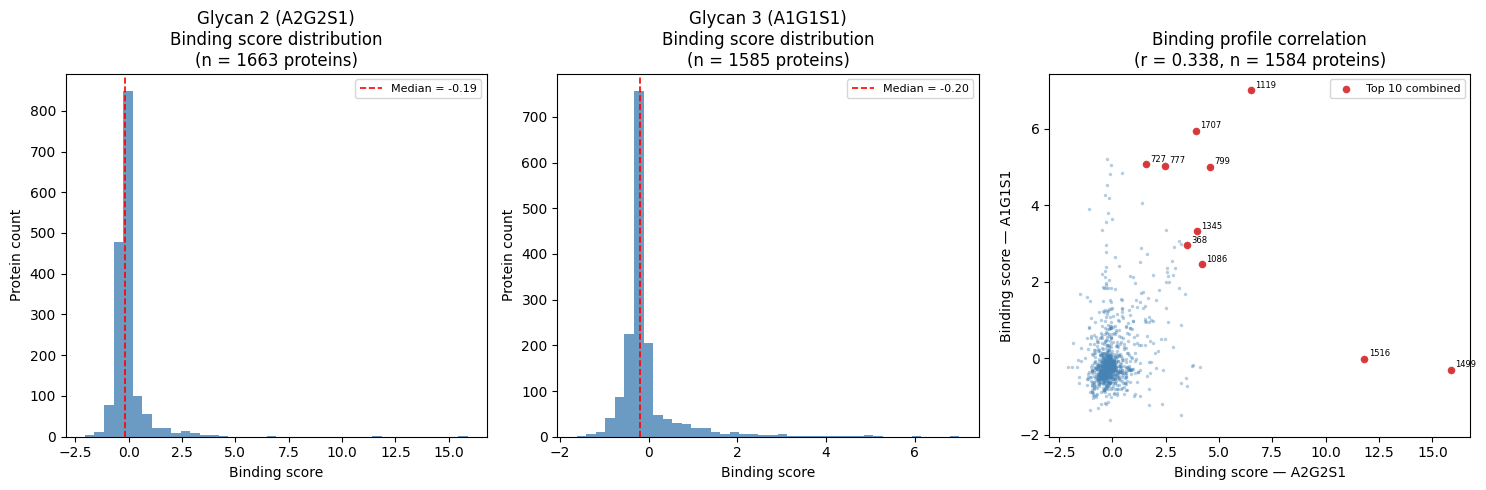

In [16]:
# ── Binding profile visualisation ─────────────────────────────────────────
if gb_direct:
    fig, axes = plt.subplots(1, len(gb_direct) + 1, figsize=(5 * (len(gb_direct) + 1), 5))
    if len(gb_direct) == 1:
        axes = [axes, None]

    # Score distributions
    for ax_i, (idx, bs) in enumerate(gb_direct.items()):
        ax = axes[ax_i]
        scores = bs.values
        ax.hist(scores, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
        thresh = bs.median()
        ax.axvline(thresh, color="red", linestyle="--", linewidth=1.2,
                   label=f"Median = {thresh:.2f}")
        ax.set_xlabel("Binding score")
        ax.set_ylabel("Protein count")
        ax.set_title(f"Glycan {idx} ({GLYCAN_LABELS[idx]})\nBinding score distribution\n"
                     f"(n = {len(bs)} proteins)")
        ax.legend(fontsize=8)

    # Score correlation between the two directly matched glycans
    if len(gb_direct) >= 2:
        ax = axes[len(gb_direct)]
        idxs = sorted(gb_direct.keys())
        shared_prots = gb_direct[idxs[0]].index.intersection(gb_direct[idxs[1]].index)
        x = gb_direct[idxs[0]][shared_prots]
        y = gb_direct[idxs[1]][shared_prots]
        ax.scatter(x, y, s=6, alpha=0.4, c="steelblue", linewidths=0)
        # Highlight top binders
        top_idx = (x + y).nlargest(10).index
        ax.scatter(x[top_idx], y[top_idx], s=30, alpha=0.9, c="#d62728", linewidths=0,
                   label="Top 10 combined")
        for prot in top_idx:
            ax.annotate(str(prot), xy=(x[prot], y[prot]),
                        xytext=(3, 2), textcoords="offset points", fontsize=6)
        corr = np.corrcoef(x.values, y.values)[0, 1]
        ax.set_xlabel(f"Binding score — {GLYCAN_LABELS[idxs[0]]}")
        ax.set_ylabel(f"Binding score — {GLYCAN_LABELS[idxs[1]]}")
        ax.set_title(f"Binding profile correlation\n(r = {corr:.3f}, n = {len(shared_prots)} proteins)")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_protein_binding.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No direct binding data available to plot.")

**Interpretation:** The binding score distribution reveals that most proteins bind the identified glycans weakly (scores clustered near zero, median ≈ −0.2), with a long right tail of strong binders — a right-skewed distribution typical of glycan microarray data where specific lectins and glycan-binding proteins account for a small fraction of total interactions. The high-score tail contains the biologically relevant binding partners.

The binding profiles of glycans 2 (A2G2S1) and 3 (A1G1S1) show substantial overlap: 494 of ~830 strong binders are shared (~60%), consistent with their structural similarity — both are monosialylated N-glycans differing only in one Gal residue on the antenna. Proteins in the top-right quadrant of the scatter plot are high-affinity binders of both glycans and represent the most biologically relevant interaction partners for follow-up investigation.

The shared strong-binder set across both directly matched glycans is the highest-confidence protein panel for further characterisation. These proteins may include lectins, galectins, or sialic-acid-recognising receptors known to mediate cancer-relevant signalling.


## 8 · Save Results

| Key | Contents |
|-----|----------|
| `glycan_list` | Original 5-row glycan table with parsed composition and match flags |
| `match_strategy` | `"exact"` or `"composition"` per glycan |
| `exact_matches` | Subset of df_glycan for exact-match glycans |
| `comp_matches` | Subset of df_glycan for composition-match glycans |
| `disease_results` | Per-glycan disease association counts and top diseases |
| `tissue_results` | Per-glycan tissue counts |
| `species_results` | Per-glycan species counts |
| `gb_direct` | Direct binding profiles (glycans 2 & 3) |
| `gb_proxy` | Proxy binding profiles (composition-based) |
| `annot_trimmed` | Structural motif annotation table |

In [17]:
enrichment_output = {
    "glycan_list":     glycan_list,
    "glycan_labels":   GLYCAN_LABELS,
    "match_strategy":  match_strategy,
    "exact_matches":   exact_matches,
    "comp_matches":    comp_matches,
    "disease_results": disease_results,
    "tissue_results":  tissue_results,
    "species_results": species_results,
    "gb_direct":       gb_direct,
    "gb_proxy":        gb_proxy,
    "annot_trimmed":   annot_trimmed,
    "all_disease_counts":  dict(all_disease_counts),
    "all_tissue_counts":   dict(all_tissues),
    "all_species_counts":  dict(all_species),
}

out_path = RES_DIR / "enrichment_results.pkl"
with open(out_path, "wb") as f:
    pickle.dump(enrichment_output, f)

print(f"Saved: {out_path}")
print()
print("=== Enrichment Summary ===")
print(f"  Identified glycans     : {len(glycan_list)}")
print(f"  Exact DB matches       : {sum(s=='exact' for s in match_strategy.values())} / {len(match_strategy)}")
print(f"  Composition matches    : {sum(s=='composition' for s in match_strategy.values())} / {len(match_strategy)}")
print(f"  Direct GB binding data : {len(gb_direct)} glycans")
print(f"  Unique diseases found  : {len(all_disease_counts)}")

# Cancer-related diseases
cancer_total = {d: n for d, n in all_disease_counts.items()
                if "cancer" in d.lower() or "carcinoma" in d.lower()
                or "tumor" in d.lower() or "leukemia" in d.lower()}
print(f"  Cancer-related diseases: {len(cancer_total)}: {sorted(cancer_total.keys())}")

# Lung cancer specifically
lung_cancer = {d: n for d, n in all_disease_counts.items() if "lung" in d.lower()}
print(f"  Lung-cancer associations: {lung_cancer}")

Saved: ../files/results/enrichment_results.pkl

=== Enrichment Summary ===
  Identified glycans     : 5
  Exact DB matches       : 3 / 5
  Composition matches    : 2 / 5
  Direct GB binding data : 2 glycans
  Unique diseases found  : 10
  Cancer-related diseases: 5: ['colorectal_cancer', 'esophageal_cancer', 'female_breast_cancer', 'gastric_cancer', 'lung_non_small_cell_carcinoma']
  Lung-cancer associations: {'lung_non_small_cell_carcinoma': 1}
